In [3]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/playground-series-s6e1/sample_submission.csv
/kaggle/input/playground-series-s6e1/train.csv
/kaggle/input/playground-series-s6e1/test.csv
/kaggle/input/exam-score-prediction-dataset/Exam_Score_Prediction.csv


### Import Libraries

In [4]:
! pip install pytabkit
import pandas as pd, numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
from xgboost  import XGBRegressor
from xgboost import plot_importance

import torch
from pytabkit import TabM_D_Regressor

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 364.0/364.0 kB 10.0 MB/s eta 0:00:0000:01


In [5]:
import  xgboost as xgb
import importlib.metadata

### Load data

In [6]:
train = pd.read_csv("/kaggle/input/playground-series-s6e1/train.csv")
print("Train shape:", train.shape )
train.head(1)

Train shape: (630000, 13)


,id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,0,21,female,b.sc,7.91,98.8,no,4.9,average,online videos,low,easy,78.3


In [7]:
test = pd.read_csv("/kaggle/input/playground-series-s6e1/test.csv")
print("Test shape:", test.shape )
test.head(1)

Test shape: (270000, 12)


,id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty
0,630000,24,other,ba,6.85,65.2,yes,5.2,poor,group study,high,easy


In [8]:
orig = pd.read_csv("/kaggle/input/exam-score-prediction-dataset/Exam_Score_Prediction.csv")
print("Original data shape:", orig.shape )
orig.head(1)

Original data shape: (20000, 13)


,student_id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,1,17,male,diploma,2.78,92.9,yes,7.4,poor,coaching,low,hard,58.9


### Basic Feature Engineering

In [9]:
orig.columns

Index(['student_id', 'age', 'gender', 'course', 'study_hours',
       'class_attendance', 'internet_access', 'sleep_hours', 'sleep_quality',
       'study_method', 'facility_rating', 'exam_difficulty', 'exam_score'],
      dtype='object')

In [10]:
train.select_dtypes(include =['object']).columns

Index(['gender', 'course', 'internet_access', 'sleep_quality', 'study_method',
       'facility_rating', 'exam_difficulty'],
      dtype='object')

In [11]:
TARGET = "exam_score"
CATS = ["gender","course","internet_access","study_method","sleep_quality","facility_rating","exam_difficulty"]
FEATURES = ['age', 'gender', 'course', 'study_hours', 'class_attendance', 'internet_access', 'sleep_hours', 'sleep_quality', 'study_method', 'facility_rating', 'exam_difficulty']
print(f"There are {len(FEATURES)} features.")


There are 11 features.


In [12]:
# https://www.kaggle.com/competitions/playground-series-s6e1/discussion/665915
def formula(df):
    f = (6*df.study_hours + 0.35*df.class_attendance + 1.5*df.sleep_hours +
                 5*(df.sleep_quality=='good') + -5*(df.sleep_quality=='poor') +
                 10*(df.study_method=='coaching') + 5*(df.study_method=='mixed') + 2*(df.study_method=='group study') + 1*(df.study_method=='online videos') +
                 4*(df.facility_rating=='high') + -4*(df.facility_rating=='low') )
    return f

for df in [train, test, orig]:
    df['formula'] = formula(df)

In [13]:
ordinal_maps = {
    "gender" : {"male":0, "female":1, "other":2},
    "internet_access" : {"no":0, "yes":1},
    "sleep_quality" : {"poor":0, "average":1, "good":2},
    "facility_rating" : {"low":0, "medium":1, "high":2},
    "exam_difficulty" : {"easy":0, "moderate":1, "hard":2},
    "course" : {"ba":0, "b.sc":1, "diploma":2, "b.tech":3, "b.com":4, "bca":5, "bba":6},
    "study_method" : {"self-study":0, "online videos":1, "group study":2, "mixed":3, "coaching":4},
}

for df in [train, test, orig]:
    for c in CATS:
        df[c] = df[c].map(ordinal_maps[c]).fillna(-1).astype('int32')

In [14]:
train.head()

,id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score,formula
0,0,21,1,1,7.91,98.8,0,4.9,1,1,0,0,78.3,86.390
1,1,18,2,2,4.95,94.8,1,4.7,0,0,1,1,46.7,64.930
2,2,20,1,1,4.68,92.6,1,5.8,0,4,2,1,99.0,78.190
3,3,19,0,1,2.00,49.5,1,8.3,1,2,2,1,63.9,47.775
4,4,23,0,5,7.65,86.9,1,9.6,2,0,2,0,100.0,99.715


In [15]:
NEW_CATS = []
for c in FEATURES:
    n = f"CAT_{c}"
    NEW_CATS.append(n)

    train[n]  = train[c].copy()
    test[n] = test[c].copy()
    orig[n] = orig[c].copy()


    combine = pd.concat([train[n], test[n], orig[n]], axis =0)
    v,_ = combine.factorize()
    train[n] = v[:len(train)]
    test[n] = v[len(train):len(train)+len(test)]
    orig[n] = v[len(train)+len(test):]
    for df in [train, test, orig]:
        df[n] = df[n].astype("int32")

FEATURES += ['formula'] + NEW_CATS
print(f"Now there are {len(FEATURES)} features.")


Now there are 23 features.


In [16]:
xgb_params = {
    "n_estimators": 1000,           
    "learning_rate": 0.01,          
    "max_depth": 8,                  
    "subsample": 0.8,               
    "colsample_bytree": 0.35,        
    "min_child_weight": 5,           
    "early_stopping_rounds": 100,   
    "eval_metric": "rmse",
    "enable_categorical": True,
    "device": "cuda",
    "random_state": 42,
}

tabm_params = {
    "verbosity": 0,
    "arch_type": "tabm-mini-normal",
    "tabm_k": 24, 
    "num_emb_type": "pwl", 
    "d_embedding": 8,
    "batch_size": 256,
    "lr": 1e-3, 
    "n_epochs": 100, 
    "dropout": 0.11, 
    "d_block": 256, 
    "n_blocks": 5, 
    "patience": 4, 
    "weight_decay": 1e-2, 
    "device": "cpu",
    "random_state": 42,
}

In [17]:
N_SPLITS = 10

# PREPARE DATA
X = train[FEATURES]
X_test = test[FEATURES]
X_orig = orig[FEATURES]
y = train[TARGET].values
y_orig = orig[TARGET].values

# STORE OOF AND TEST PREDS
oof_preds_xgb = np.zeros(len(train))
test_preds_xgb = np.zeros(len(test))

# KFOLD TRAIN AND VALIDATE
kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=42)

for fold, (train_idx, val_idx) in enumerate(kf.split(X), 1):
    print("#"*25)
    print(f"### FOLD {fold}")
    print("#"*25)
    
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]

    # ADD ORIGINAL DATA
    X_train = pd.concat([X_train,X_orig],axis=0)
    y_train = np.concatenate([y_train,y_orig],axis=0)
    model = XGBRegressor(**xgb_params)
    # TRAIN TABM
    model.fit(
        X_train,
        y_train,
        eval_set=[(X_val, y_val)],
        verbose=200,
    )
    oof_preds = model.predict(X_val)
    test_preds = model.predict(X_test)

    # PSEUDO LABEL WITH TABM FOR XGB
    X_train_xgb = pd.concat([X_train,X_val,X_test],axis=0)
    y_train_xgb = np.concatenate([y_train,oof_preds,test_preds],axis=0)

    # PREPARE CATS FOR XGB
    for c in NEW_CATS:
        X_train_xgb[c] = X_train_xgb[c].astype('category')
    X_val_xgb = X_train_xgb.iloc[len(X_train):len(X_train)+len(X_val)]
    X_test_xgb = X_train_xgb.iloc[len(X_train)+len(X_val):]

    # TRAIN XGB WITH PSEUDO LABELS
    model = XGBRegressor(**xgb_params)
    model.fit(
        X_train_xgb,
        y_train_xgb,
        eval_set=[(X_val_xgb, y_val)],
        verbose=200,
    )
    oof_preds = model.predict(X_val_xgb)
    oof_preds_xgb[val_idx] = oof_preds

    rmse_xgb = mean_squared_error(y_val, oof_preds)**0.5
    print(f"Fold {fold} RMSE XGB w/ Pseudo: {rmse_xgb:.5f}")

    test_preds = model.predict(X_test_xgb)
    test_preds_xgb += test_preds/N_SPLITS

    # CLEAR MEMORY
    # gc.collect()
    # torch.cuda.empty_cache()

# OVERALL CV SCORE
print("-" * 40)
rmse_xgb = mean_squared_error(y, oof_preds_xgb)**0.5
print(f"OOF RMSE XGB w/ Pseudo:       {rmse_xgb:.5f}")
print()

#########################
### FOLD 1
#########################
[0]	validation_0-rmse:18.80672
[200]	validation_0-rmse:9.80160
[400]	validation_0-rmse:8.84649
[600]	validation_0-rmse:8.73236
[800]	validation_0-rmse:8.70404
[999]	validation_0-rmse:8.68968


/usr/local/lib/python3.12/dist-packages/xgboost/core.py:774: UserWarning: [07:03:43] WARNING: /workspace/src/common/error_msg.cc:41: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


[0]	validation_0-rmse:18.73477
[200]	validation_0-rmse:9.41388
[400]	validation_0-rmse:8.68482
[600]	validation_0-rmse:8.61946
[800]	validation_0-rmse:8.60577
[999]	validation_0-rmse:8.60050
Fold 1 RMSE XGB w/ Pseudo: 8.60050
#########################
### FOLD 2
#########################
[0]	validation_0-rmse:18.81150
[200]	validation_0-rmse:9.83751
[400]	validation_0-rmse:8.89330
[600]	validation_0-rmse:8.78279
[800]	validation_0-rmse:8.75706
[999]	validation_0-rmse:8.74352
[0]	validation_0-rmse:18.73980
[200]	validation_0-rmse:9.46058
[400]	validation_0-rmse:8.73646
[600]	validation_0-rmse:8.67069
[800]	validation_0-rmse:8.65792
[999]	validation_0-rmse:8.65353
Fold 2 RMSE XGB w/ Pseudo: 8.65353
#########################
### FOLD 3
#########################
[0]	validation_0-rmse:18.85691
[200]	validation_0-rmse:9.81480
[400]	validation_0-rmse:8.85065
[600]	validation_0-rmse:8.73481
[800]	validation_0-rmse:8.70664
[999]	validation_0-rmse:8.69239
[0]	validation_0-rmse:18.78476
[200]	val

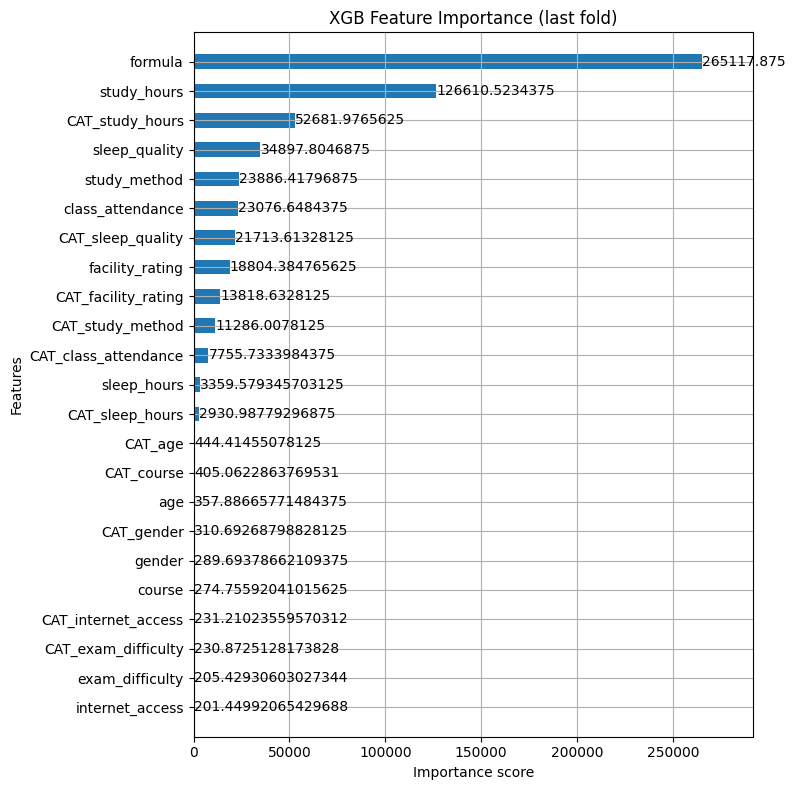

In [18]:
fig, ax = plt.subplots(figsize=(8, 8))  
plot_importance(
    model,
    ax=ax,
    importance_type="gain", # or "weight", "cover"
    max_num_features=40,
    height=0.5,
)
ax.set_title("XGB Feature Importance (last fold)")
fig.tight_layout()
plt.show()

In [19]:
rmse_xgb = mean_squared_error(y, oof_preds_xgb)**0.5
print(f"OOF RMSE XGB w/ Pseudo:       {rmse_xgb:.5f}")

OOF RMSE XGB w/ Pseudo:       8.63675


In [20]:
np.save("oof_xgb",oof_preds_xgb)
np.save("test_preds_xgb",test_preds_xgb)

In [21]:
sub = pd.read_csv("/kaggle/input/playground-series-s6e1/sample_submission.csv")
sub['exam_score'] = np.clip(test_preds_xgb,19.6,100)
sub.to_csv("submission.csv",index=False)
sub.head()

,id,exam_score
0,630000,70.251427
1,630001,68.892231
2,630002,90.030970
3,630003,55.818788
4,630004,45.911486


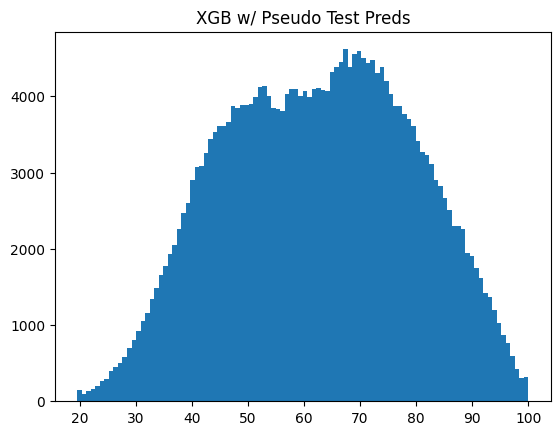

In [22]:
plt.hist(sub['exam_score'],bins=100)
plt.title("XGB w/ Pseudo Test Preds")
plt.show()